Shahriar, Sakib; Tariq, Usman (2021). Maqam478: Qur'anic Recitations in 8 different Maqams. figshare. Dataset. https://doi.org/10.6084/m9.figshare.13489359.v1

In [ ]:
import requests
import os
import zipfile
import librosa
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf

In [ ]:
article_id = 13489359  # from the DOI 10.6084/m9.figshare.13489359
resp = requests.get(f"https://api.figshare.com/v2/articles/{article_id}")
resp.raise_for_status()
data = resp.json()

print(data)

{'files': [{'id': 26372272, 'name': 'Maqam478.zip', 'size': 3585820308, 'is_link_only': False, 'download_url': 'https://ndownloader.figshare.com/files/26372272', 'supplied_md5': '0f2060c690b465e717c9c91f02cf29f0', 'computed_md5': '0f2060c690b465e717c9c91f02cf29f0', 'mimetype': 'application/zip'}], 'folder_structure': {}, 'authors': [{'id': 9918567, 'full_name': 'Sakib Shahriar', 'first_name': 'Sakib', 'last_name': 'Shahriar', 'is_active': True, 'url_name': 'Sakib_Shahriar', 'orcid_id': ''}, {'id': 9918568, 'full_name': 'Usman Tariq', 'first_name': 'Usman', 'last_name': 'Tariq', 'is_active': False, 'url_name': '_', 'orcid_id': '0000-0002-8244-2165'}], 'custom_fields': [], 'figshare_url': 'https://figshare.com/articles/dataset/Maqam478_Qur_anic_Recitations_in_8_different_Maqams/13489359', 'download_disabled': False, 'description': "<div>A dataset conatining <b>478 Qur'anic audio recitations</b> in <b>8 different maqams</b>. The dataset is intended to be used for the purpose of maqam clas

In [ ]:
os.makedirs("/content/maqam478", exist_ok=True)

for f in data["files"]:
    url = f["download_url"]
    out_path = f"/content/maqam478/{f['name']}"
    print(f"Downloading {f['name']} ({f['size']/1e6:.1f} MB)...")
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(out_path, "wb") as out:
        for chunk in r.iter_content(chunk_size=8192):
            out.write(chunk)
print("Done.")

Done.


In [ ]:
for fname in os.listdir("/content/maqam478"):
    if fname.endswith(".zip"):
        with zipfile.ZipFile(f"/content/maqam478/{fname}") as z:
            z.extractall("/content/maqam478/extracted")

In [ ]:
label_map = {
    "Ajam": 0, "Bayat": 1, "Hijaz": 2, "Kurd": 3,
    "Nahawand": 4, "Rast": 5, "Saba": 6, "Seka": 7
}

def audio_inventory(audio_dir, label_map):
    rows = []
    for maqam_folder in label_map.keys():
        folder_path = os.path.join(audio_dir, maqam_folder)
        for fname in os.listdir(folder_path):
            if not fname.endswith(".wav"):
                continue
            fpath = os.path.join(folder_path, fname)
            duration = librosa.get_duration(path=fpath)
            sr = librosa.get_samplerate(fpath)
            rows.append({
                "maqam": maqam_folder,
                "filename": fname,
                "duration_sec": duration,
                "sample_rate": sr,
                "filesize_kb": os.path.getsize(fpath) / 1024
            })
    return pd.DataFrame(rows)

df = audio_inventory("/content/maqam478/extracted/Maqam478/Dataset", label_map)

In [ ]:
df.head()

,maqam,filename,duration_sec,sample_rate,filesize_kb
0,Ajam,Ajam_14.wav,30.432,48000,5708.902344
1,Ajam,Ajam_43.wav,44.904,48000,8422.402344
2,Ajam,Ajam_24.wav,43.320,48000,8125.402344
3,Ajam,Ajam_29.wav,47.232,48000,8858.902344
4,Ajam,Ajam_15.wav,32.352,48000,6068.902344


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   maqam         478 non-null    object 
 1   filename      478 non-null    object 
 2   duration_sec  478 non-null    float64
 3   sample_rate   478 non-null    int64  
 4   filesize_kb   478 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 18.8+ KB


This descipotion shows that the range of duration varies from 27 seconds to 65 seconds and the sample rate is 48000. These informations tell us that the records are inconsistant and the sample rate is high for the deep learning model to train that may take even longer. I suggest to take sr=16000 or sr=22050.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_sec,478.0,44.136504,7.94934,27.456000,37.968000,43.320000,50.298000,65.424000
sample_rate,478.0,48000.000000,0.00000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
filesize_kb,478.0,8281.727065,1490.55460,5150.892578,7122.500977,8125.397461,9433.767578,12269.892578


In [ ]:
df.describe(include=object).T

,count,unique,top,freq
maqam,478,8,Hijaz,71
filename,478,478,Seka_33.wav,1


In [ ]:
base_audio_path = '/content/maqam478/extracted/Maqam478/Dataset'

# Perform a stratified split based on 'maqam' to prevent data leakage
# We will split the DataFrame into train and test sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2, # 20% for testing, 80% for training
    stratify=df['maqam'], # Stratify by maqam to maintain class distribution
    random_state=42 # for reproducibility
)

print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Train set size: 382
Test set size: 96


In [ ]:
# Create directories for train and test sets
train_dir = os.path.join(base_audio_path, 'train')
test_dir = os.path.join(base_audio_path, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Create subdirectories for each maqam within train and test
for maqam in label_map.keys():
    os.makedirs(os.path.join(train_dir, maqam), exist_ok=True)
    os.makedirs(os.path.join(test_dir, maqam), exist_ok=True)

print(f"Created train directory: {train_dir}")
print(f"Created test directory: {test_dir}")

Created train directory: /content/maqam478/extracted/Maqam478/Dataset/train
Created test directory: /content/maqam478/extracted/Maqam478/Dataset/test


In [ ]:
# Function to move files
def move_files(df, destination_base_dir):
    for index, row in df.iterrows():
        maqam_folder = row['maqam']
        filename = row['filename']

        source_path = os.path.join(base_audio_path, maqam_folder, filename)
        destination_path = os.path.join(destination_base_dir, maqam_folder, filename)

        # Ensure the source file exists before moving
        if os.path.exists(source_path):
            shutil.move(source_path, destination_path)
        else:
            print(f"Warning: Source file not found: {source_path}")

# Move files for the training set
print("Moving training files...")
move_files(train_df, train_dir)

# Move files for the testing set
print("Moving testing files...")
move_files(test_df, test_dir)

print("Data splitting and file movement complete.")

Moving training files...
Moving testing files...
Data splitting and file movement complete.


In [ ]:
train_df = audio_inventory(train_dir, label_map)
test_df = audio_inventory(test_dir, label_map)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   maqam         382 non-null    object 
 1   filename      382 non-null    object 
 2   duration_sec  382 non-null    float64
 3   sample_rate   382 non-null    int64  
 4   filesize_kb   382 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 15.1+ KB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   maqam         96 non-null     object 
 1   filename      96 non-null     object 
 2   duration_sec  96 non-null     float64
 3   sample_rate   96 non-null     int64  
 4   filesize_kb   96 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 3.9+ KB


/tmp/ipykernel_1006/1132806535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='maqam', data=train_df, order=df['maqam'].value_counts().index, palette='viridis')


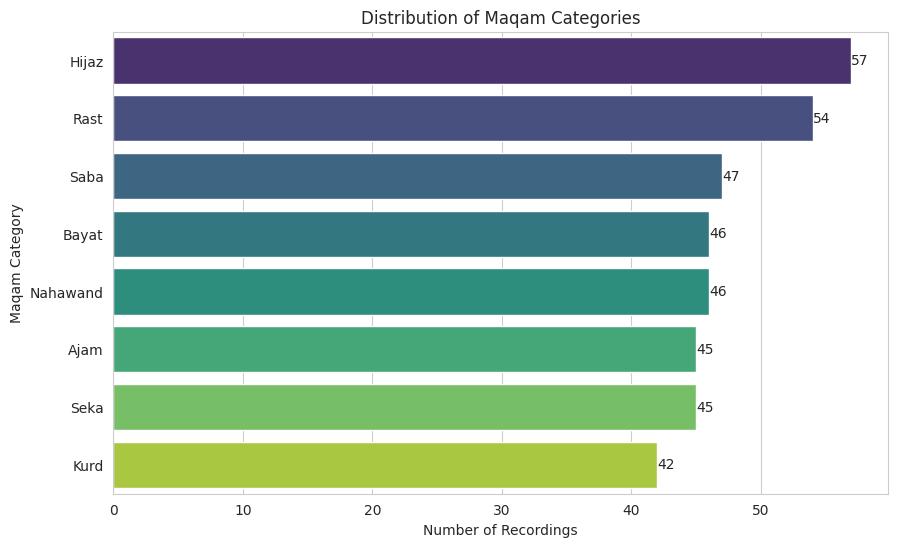

In [ ]:
sns.set_style("whitegrid")

# 1. Distribution of 'maqam'
plt.figure(figsize=(10, 6))
ax = sns.countplot(y='maqam', data=train_df, order=df['maqam'].value_counts().index, palette='viridis')
plt.title('Distribution of Maqam Categories')
plt.xlabel('Number of Recordings')
plt.ylabel('Maqam Category')

# Add the count of each category at the end of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

/tmp/ipykernel_1006/4139623818.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(train_df['duration_sec'], kde=True, bins=30, palette='magma')


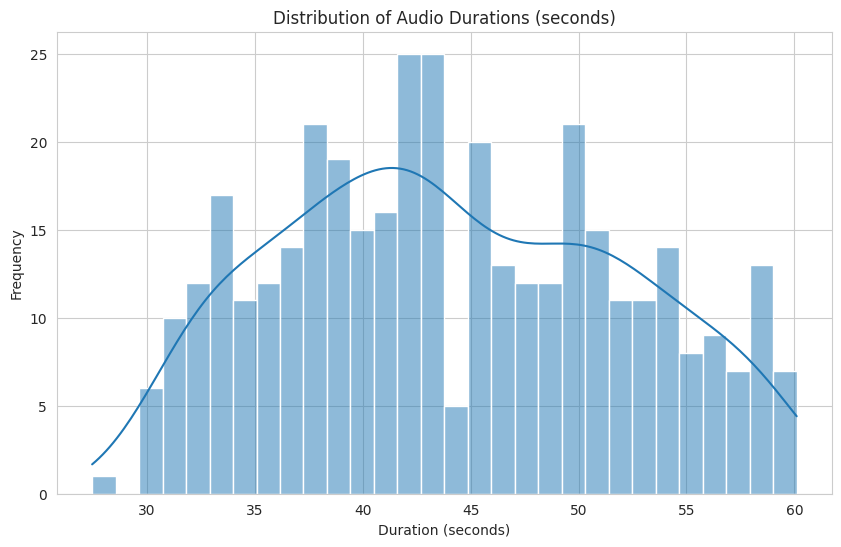

In [ ]:
# 2. Distribution of 'duration_sec'
plt.figure(figsize=(10, 6))
sns.histplot(train_df['duration_sec'], kde=True, bins=30, palette='magma')
plt.title('Distribution of Audio Durations (seconds)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

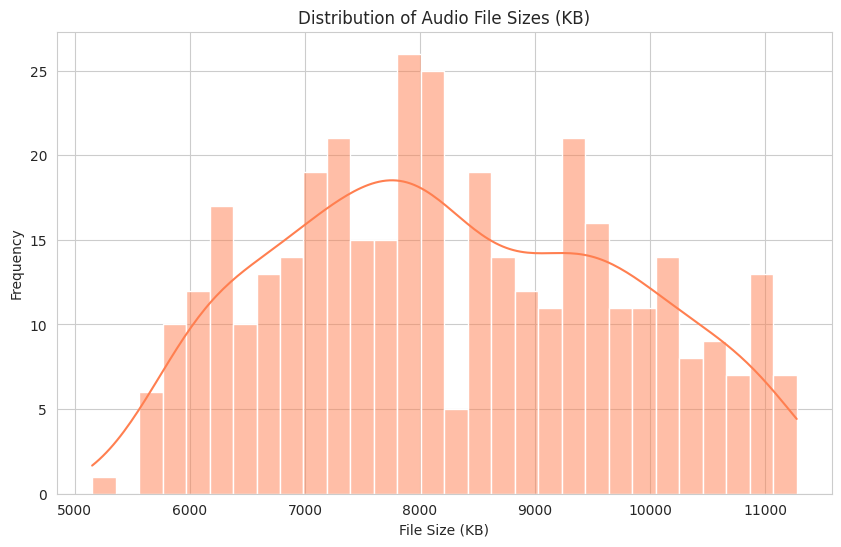

In [ ]:
# 3. Distribution of 'filesize_kb'
plt.figure(figsize=(10, 6))
sns.histplot(train_df['filesize_kb'], kde=True, bins=30, color='coral')
plt.title('Distribution of Audio File Sizes (KB)')
plt.xlabel('File Size (KB)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1006/450708011.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='maqam', y='duration_sec', data=train_df, palette='cividis')


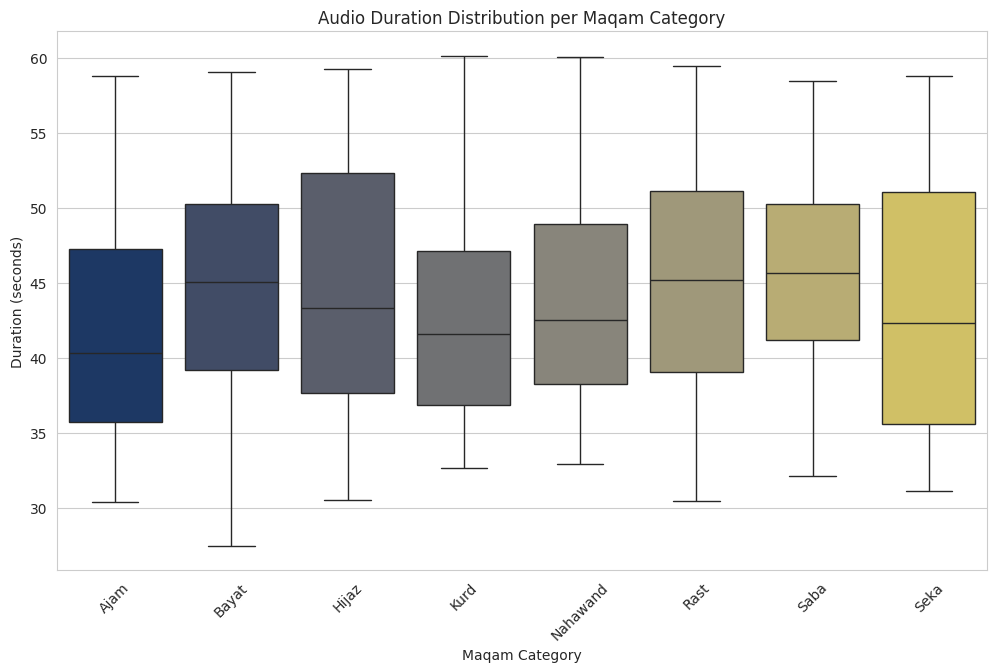

In [ ]:
# 4. Relationship between 'maqam' and 'duration_sec' using a box plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='maqam', y='duration_sec', data=train_df, palette='cividis')
plt.title('Audio Duration Distribution per Maqam Category')
plt.xlabel('Maqam Category')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
processed_merged_train_dir = os.path.join(base_audio_path, 'processed_merged_train_30s')
os.makedirs(processed_merged_train_dir, exist_ok=True)

segment_duration = 30 # seconds
processed_merged_train_data = []

print(f"Processing train audio files: Merging by maqam and splitting into {segment_duration}-second segments...")

for maqam in train_df['maqam'].unique():
    print(f"  Processing maqam: {maqam}")
    maqam_df = train_df[train_df['maqam'] == maqam]

    # Create a subdirectory for the current maqam in the processed output
    maqam_output_dir = os.path.join(processed_merged_train_dir, maqam)
    os.makedirs(maqam_output_dir, exist_ok=True)

    all_audio_for_maqam = []
    sr_current = None

    # Load and concatenate all audio for the current maqam
    for index, row in maqam_df.iterrows():
        full_audio_path = os.path.join(train_dir, row['maqam'], row['filename'])
        try:
            y_single, sr_single = librosa.load(full_audio_path, sr=None)
            if sr_current is None:
                sr_current = sr_single
            elif sr_current != sr_single:
                print(f"Warning: Sample rate mismatch for {full_audio_path}. Expected {sr_current}, got {sr_single}. Resampling to {sr_current}.")
                y_single = librosa.resample(y_single, orig_sr=sr_single, target_sr=sr_current)
            all_audio_for_maqam.append(y_single)
        except Exception as e:
            print(f"Error loading {full_audio_path}: {e}")
            continue

    if not all_audio_for_maqam:
        print(f"No audio files processed for maqam {maqam}. Skipping segmentation.")
        continue

    y_merged_maqam = np.concatenate(all_audio_for_maqam)

    # Split the merged audio into 30-second segments
    segment_length_samples = segment_duration * sr_current
    num_segments = int(len(y_merged_maqam) / segment_length_samples)

    for i in range(num_segments):
        start_sample = i * segment_length_samples
        end_sample = (i + 1) * segment_length_samples
        segment = y_merged_maqam[start_sample:end_sample]

        segment_filename = f"{maqam}_merged_seg{i}.wav"
        segment_save_path = os.path.join(maqam_output_dir, segment_filename)

        try:
            sf.write(segment_save_path, segment, sr_current)

            processed_merged_train_data.append({
                'maqam': maqam,
                'original_filename_group': f"{maqam}_merged",
                'segment_filename': segment_filename,
                'duration_sec': segment_duration,
                'sample_rate': sr_current,
                'filepath': segment_save_path
            })
        except Exception as e:
            print(f"Error saving segment {segment_filename}: {e}")

processed_merged_train_df = pd.DataFrame(processed_merged_train_data)

print("Processing complete for training data. Displaying first 5 rows of processed_merged_train_df:")
display(processed_merged_train_df.head())
print("\nInfo of processed_merged_train_df:")
display(processed_merged_train_df.info())

Processing train audio files: Merging by maqam and splitting into 30-second segments...
  Processing maqam: Ajam
  Processing maqam: Bayat
  Processing maqam: Hijaz
  Processing maqam: Kurd
  Processing maqam: Nahawand
  Processing maqam: Rast
  Processing maqam: Saba
  Processing maqam: Seka
Processing complete for training data. Displaying first 5 rows of processed_merged_train_df:


,maqam,original_filename_group,segment_filename,duration_sec,sample_rate,filepath
0,Ajam,Ajam_merged,Ajam_merged_seg0.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
1,Ajam,Ajam_merged,Ajam_merged_seg1.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
2,Ajam,Ajam_merged,Ajam_merged_seg2.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
3,Ajam,Ajam_merged,Ajam_merged_seg3.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
4,Ajam,Ajam_merged,Ajam_merged_seg4.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...



Info of processed_merged_train_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   maqam                    558 non-null    object
 1   original_filename_group  558 non-null    object
 2   segment_filename         558 non-null    object
 3   duration_sec             558 non-null    int64 
 4   sample_rate              558 non-null    int64 
 5   filepath                 558 non-null    object
dtypes: int64(2), object(4)
memory usage: 26.3+ KB


None

In [ ]:
processed_merged_test_dir = os.path.join(base_audio_path, 'processed_merged_test_30s')
os.makedirs(processed_merged_test_dir, exist_ok=True)

processed_merged_test_data = []

print(f"Processing test audio files: Merging by maqam and splitting into {segment_duration}-second segments...")

for maqam in test_df['maqam'].unique():
    print(f"  Processing maqam: {maqam}")
    maqam_df = test_df[test_df['maqam'] == maqam]

    # Create a subdirectory for the current maqam in the processed output
    maqam_output_dir = os.path.join(processed_merged_test_dir, maqam)
    os.makedirs(maqam_output_dir, exist_ok=True)

    all_audio_for_maqam = []
    sr_current = None

    # Load and concatenate all audio for the current maqam
    for index, row in maqam_df.iterrows():
        full_audio_path = os.path.join(test_dir, row['maqam'], row['filename'])
        try:
            y_single, sr_single = librosa.load(full_audio_path, sr=None)
            if sr_current is None:
                sr_current = sr_single
            elif sr_current != sr_single:
                print(f"Warning: Sample rate mismatch for {full_audio_path}. Expected {sr_current}, got {sr_single}. Resampling to {sr_current}.")
                y_single = librosa.resample(y_single, orig_sr=sr_single, target_sr=sr_current)
            all_audio_for_maqam.append(y_single)
        except Exception as e:
            print(f"Error loading {full_audio_path}: {e}")
            continue

    if not all_audio_for_maqam:
        print(f"No audio files processed for maqam {maqam}. Skipping segmentation.")
        continue

    y_merged_maqam = np.concatenate(all_audio_for_maqam)

    # Split the merged audio into 30-second segments
    segment_length_samples = segment_duration * sr_current
    num_segments = int(len(y_merged_maqam) / segment_length_samples)

    for i in range(num_segments):
        start_sample = i * segment_length_samples
        end_sample = (i + 1) * segment_length_samples
        segment = y_merged_maqam[start_sample:end_sample]

        segment_filename = f"{maqam}_merged_seg{i}.wav"
        segment_save_path = os.path.join(maqam_output_dir, segment_filename)

        try:
            sf.write(segment_save_path, segment, sr_current)

            processed_merged_test_data.append({
                'maqam': maqam,
                'original_filename_group': f"{maqam}_merged",
                'segment_filename': segment_filename,
                'duration_sec': segment_duration,
                'sample_rate': sr_current,
                'filepath': segment_save_path
            })
        except Exception as e:
            print(f"Error saving segment {segment_filename}: {e}")

processed_merged_test_df = pd.DataFrame(processed_merged_test_data)

print("Processing complete for testing data. Displaying first 5 rows of processed_merged_test_df:")
display(processed_merged_test_df.head())
print("\nInfo of processed_merged_test_df:")
display(processed_merged_test_df.info())

Processing test audio files: Merging by maqam and splitting into 30-second segments...
  Processing maqam: Ajam
  Processing maqam: Bayat
  Processing maqam: Hijaz
  Processing maqam: Kurd
  Processing maqam: Nahawand
  Processing maqam: Rast
  Processing maqam: Saba
  Processing maqam: Seka
Processing complete for testing data. Displaying first 5 rows of processed_merged_test_df:


,maqam,original_filename_group,segment_filename,duration_sec,sample_rate,filepath
0,Ajam,Ajam_merged,Ajam_merged_seg0.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
1,Ajam,Ajam_merged,Ajam_merged_seg1.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
2,Ajam,Ajam_merged,Ajam_merged_seg2.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
3,Ajam,Ajam_merged,Ajam_merged_seg3.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...
4,Ajam,Ajam_merged,Ajam_merged_seg4.wav,30,48000,/content/maqam478/extracted/Maqam478/Dataset/p...



Info of processed_merged_test_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   maqam                    137 non-null    object
 1   original_filename_group  137 non-null    object
 2   segment_filename         137 non-null    object
 3   duration_sec             137 non-null    int64 
 4   sample_rate              137 non-null    int64 
 5   filepath                 137 non-null    object
dtypes: int64(2), object(4)
memory usage: 6.6+ KB


None

/tmp/ipykernel_1006/708687970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='maqam', data=processed_merged_train_df, order=df['maqam'].value_counts().index, palette='viridis')


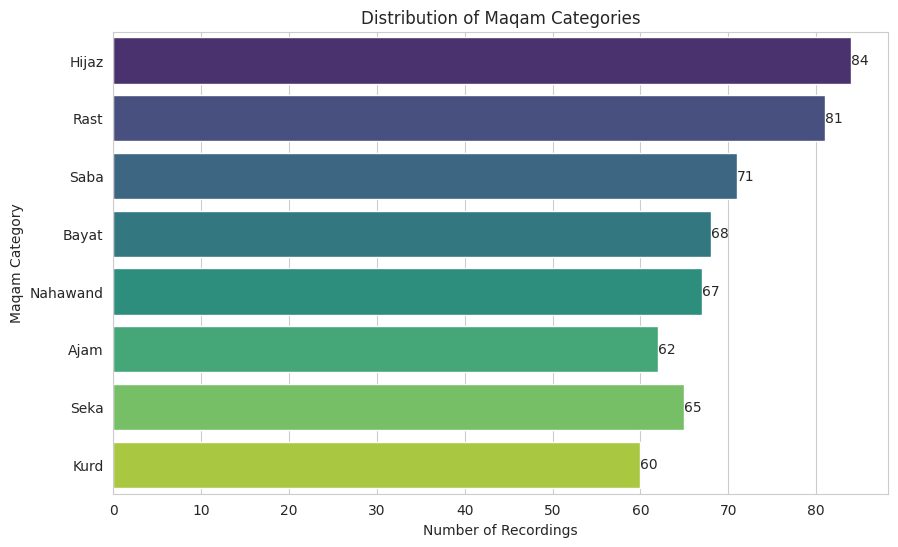

In [ ]:
sns.set_style("whitegrid")

# 1. Distribution of 'maqam'
plt.figure(figsize=(10, 6))
ax = sns.countplot(y='maqam', data=processed_merged_train_df, order=df['maqam'].value_counts().index, palette='viridis')
plt.title('Distribution of Maqam Categories')
plt.xlabel('Number of Recordings')
plt.ylabel('Maqam Category')

# Add the count of each category at the end of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

### Feature Extraction (MFCCs)

We will now extract Mel-Frequency Cepstral Coefficients (MFCCs) from the processed audio segments. MFCCs are a popular feature representation for audio, especially in speech and music analysis, as they mimic the human auditory system's response.

Given the earlier recommendation to reduce the sample rate, we will resample the audio to `16000 Hz` during the loading process to reduce computational load and memory usage for deep learning models.

In [ ]:
def extract_mfcc(audio_path, sr=22050, n_mfcc=40, max_pad_len=174):
    try:
        # Load audio with target sample rate
        y, sr_orig = librosa.load(audio_path, sr=sr, duration=30)

        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Pad or truncate MFCCs to a fixed length
        if mfccs.shape[1] > max_pad_len:
            mfccs = mfccs[:, :max_pad_len]
        else:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')

        return mfccs.T # Transpose to (time_steps, n_mfcc) for RNNs
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

In [ ]:
train_features = []
train_labels = []

print("Extracting MFCC features for training data...")
for index, row in processed_merged_train_df.iterrows():
    audio_path = row['filepath']
    maqam_label = row['maqam']

    mfccs = extract_mfcc(audio_path, sr=22050, n_mfcc=20, max_pad_len=174)

    if mfccs is not None:
        train_features.append(mfccs)
        train_labels.append(label_map[maqam_label])

# Convert to numpy arrays
X_train = np.array(train_features)
y_train = np.array(train_labels)

print(f"Finished extracting features. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Extracting MFCC features for training data...
Finished extracting features. X_train shape: (558, 174, 20), y_train shape: (558,)


In [ ]:
test_features = []
test_labels = []

print("Extracting MFCC features for testing data...")
for index, row in processed_merged_test_df.iterrows():
    audio_path = row['filepath']
    maqam_label = row['maqam']

    # Using sr=22050 and n_mfcc=20 based on previous cell's modification
    mfccs = extract_mfcc(audio_path, sr=22050, n_mfcc=20, max_pad_len=174)

    if mfccs is not None:
        test_features.append(mfccs)
        test_labels.append(label_map[maqam_label])

# Convert to numpy arrays
X_test = np.array(test_features)
y_test = np.array(test_labels)

print(f"Finished extracting features. X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Extracting MFCC features for testing data...
Finished extracting features. X_test shape: (137, 174, 20), y_test shape: (137,)


### Preparing Data for PyTorch

We need to convert our numpy arrays (`X_train`, `y_train`, `X_test`, `y_test`) into PyTorch tensors. We'll also create `TensorDataset` and `DataLoader` objects, which are essential for managing and batching data during model training in PyTorch.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long) # Use torch.long for classification labels
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 32 # You can adjust this
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")

# Check a batch from the DataLoader
for features, labels in train_loader:
    print(f"Batch features shape: {features.shape}")
    print(f"Batch labels shape: {labels.shape}")
    break

X_train_tensor shape: torch.Size([558, 174, 20])
y_train_tensor shape: torch.Size([558])
X_test_tensor shape: torch.Size([137, 174, 20])
y_test_tensor shape: torch.Size([137])
Batch features shape: torch.Size([32, 174, 20])
Batch labels shape: torch.Size([32])


### BiLSTM Model Architecture (PyTorch)

We define a `BiLSTM` class that inherits from `nn.Module`.
- **Input**: The sequence of MFCC features.
- **LSTM**: A bidirectional LSTM to process the sequence in both directions.
- **Output**: A linear layer to map the hidden representation to the 8 Maqam classes.

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout_prob=0.5):
        super(BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True)
        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout_prob)
        # Fully connected layer (hidden_size * 2 because it's bidirectional)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Take the output of the last time step
        out = out[:, -1, :]

        # Apply dropout and classification layer
        out = self.dropout(out)
        out = self.fc(out)
        return out

# Hyperparameters derived from the data extraction step
input_dim = X_train.shape[2]  # n_mfcc = 20
hidden_dim = 128
layers_count = 2
classes_count = len(label_map) # 8 classes

# Instantiate the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BiLSTM(input_dim, hidden_dim, layers_count, classes_count).to(device)

print(model)
print(f"Model initialized on: {device}")

BiLSTM(
  (lstm): LSTM(20, 128, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)
Model initialized on: cpu


### Training Configuration and Loop

We will use the following setup for training:
- **Loss Function**: `CrossEntropyLoss` for multi-class classification.
- **Optimizer**: `Adam` for adaptive learning rates.
- **Early Stopping**: A mechanism to stop training if the test accuracy does not improve for a specified number of epochs (`patience`).

In [ ]:
import time
import torch.optim as optim

# 1. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Define Training Loop with Early Stopping
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device, patience=5):
    model.train()
    start_time = time.time()

    best_test_accuracy = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = 100 * correct / total

        # --- Evaluation Phase ---
        model.eval()
        running_test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        epoch_test_loss = running_test_loss / test_total
        epoch_test_acc = 100 * test_correct / test_total

        # Save History
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')
        print(f'Test Loss:  {epoch_test_loss:.4f}, Test Acc:  {epoch_test_acc:.2f}%')

        # --- Early Stopping Logic ---
        if epoch_test_acc > best_test_accuracy:
            best_test_accuracy = epoch_test_acc
            patience_counter = 0
            # Save the best model state
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered. No improvement for {patience} epochs.")
            break

    end_time = time.time()
    print(f'\nFinished Training in {(end_time - start_time):.2f} seconds')
    return history

# 3. Execute Training
num_epochs = 50
history = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device, patience=7)

Epoch [1/50]
Train Loss: 2.0431, Train Acc: 19.35%
Test Loss:  1.9237, Test Acc:  29.93%
Epoch [2/50]
Train Loss: 1.8009, Train Acc: 38.71%
Test Loss:  1.6053, Test Acc:  40.88%
Epoch [3/50]
Train Loss: 1.4940, Train Acc: 47.67%
Test Loss:  1.4566, Test Acc:  43.80%
Epoch [4/50]
Train Loss: 1.3875, Train Acc: 49.28%
Test Loss:  1.4260, Test Acc:  47.45%
Epoch [5/50]
Train Loss: 1.2661, Train Acc: 56.09%
Test Loss:  1.3404, Test Acc:  52.55%
Epoch [6/50]
Train Loss: 1.0149, Train Acc: 66.49%
Test Loss:  1.1625, Test Acc:  61.31%
Epoch [7/50]
Train Loss: 0.9596, Train Acc: 69.35%
Test Loss:  1.4888, Test Acc:  52.55%
Epoch [8/50]
Train Loss: 1.0534, Train Acc: 64.70%
Test Loss:  1.1124, Test Acc:  60.58%
Epoch [9/50]
Train Loss: 0.8350, Train Acc: 73.66%
Test Loss:  1.1748, Test Acc:  59.85%
Epoch [10/50]
Train Loss: 0.7311, Train Acc: 79.03%
Test Loss:  1.0430, Test Acc:  61.31%
Epoch [11/50]
Train Loss: 0.6242, Train Acc: 79.93%
Test Loss:  1.0065, Test Acc:  66.42%
Epoch [12/50]
Train

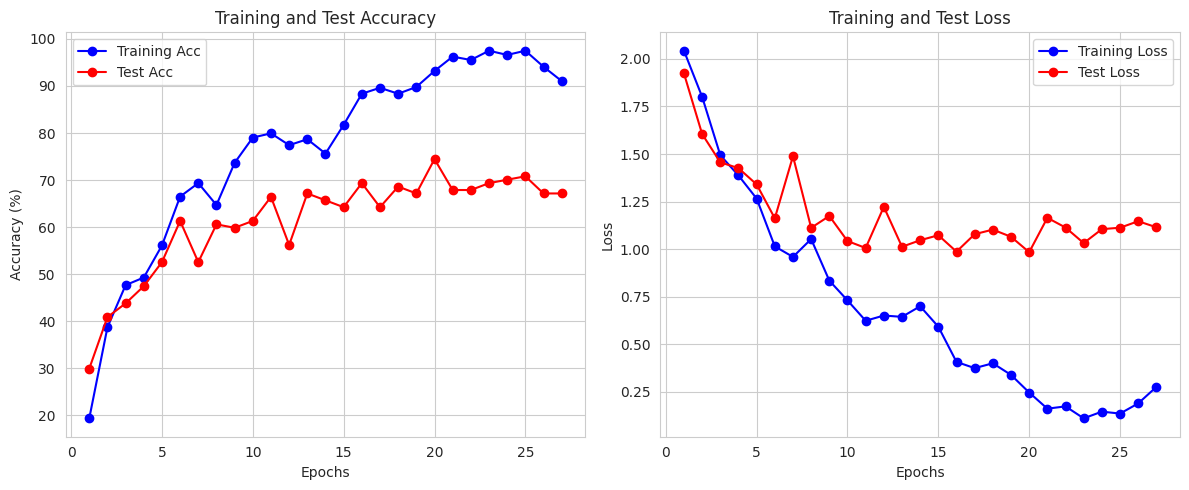

In [ ]:
def plot_history(history):
    acc = history['train_acc']
    test_acc = history['test_acc']
    loss = history['train_loss']
    test_loss = history['test_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, test_acc, 'ro-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, test_loss, 'ro-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

### Detailed Evaluation

We will now evaluate the best saved model (`best_model.pth`) on the test set to generate a confusion matrix and a classification report.

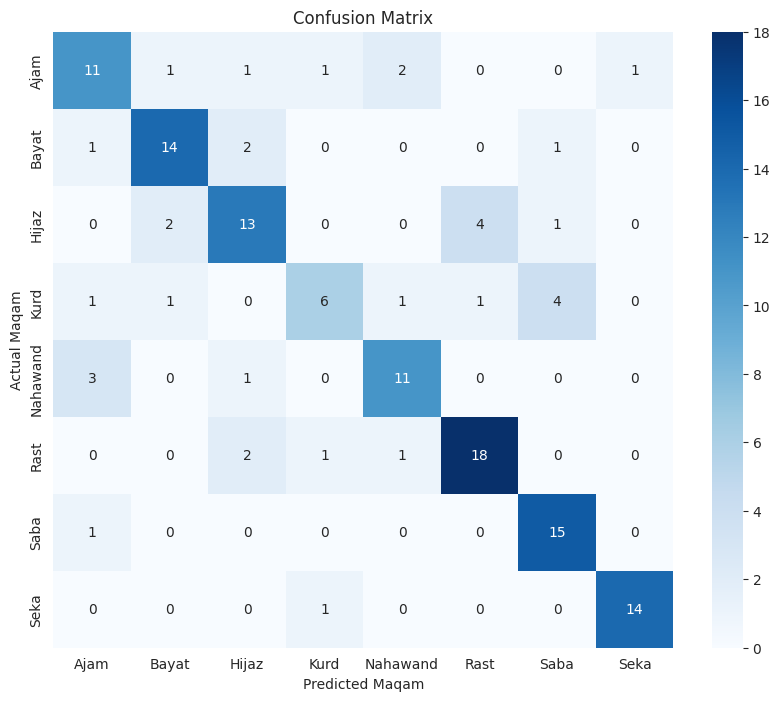

Classification Report:

              precision    recall  f1-score   support

        Ajam       0.65      0.65      0.65        17
       Bayat       0.78      0.78      0.78        18
       Hijaz       0.68      0.65      0.67        20
        Kurd       0.67      0.43      0.52        14
    Nahawand       0.73      0.73      0.73        15
        Rast       0.78      0.82      0.80        22
        Saba       0.71      0.94      0.81        16
        Seka       0.93      0.93      0.93        15

    accuracy                           0.74       137
   macro avg       0.74      0.74      0.74       137
weighted avg       0.74      0.74      0.74       137



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

# 2. Get predictions for the test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Plot Confusion Matrix
inv_label_map = {v: k for k, v in label_map.items()}
classes = [inv_label_map[i] for i in range(len(label_map))]

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual Maqam')
plt.xlabel('Predicted Maqam')
plt.show()

# 4. Print Classification Report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

In [ ]:
!pip install optuna

In [ ]:
import optuna

def objective(trial):
    # 1. Suggest Hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    hidden_size = trial.suggest_categorical("hidden_size", [64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout_prob = trial.suggest_float("dropout", 0.2, 0.6)
    patience = trial.suggest_int("patience", 5, 15)

    # 2. Setup Model, Optimizer, and Loss
    trial_model = BiLSTM(input_dim, hidden_size, num_layers, classes_count, dropout_prob).to(device)
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # 3. Simplified Training Loop for Tuning
    best_acc = 0.0
    patience_counter = 0

    for epoch in range(30): # Reduced epochs for faster tuning
        trial_model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = trial_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation
        trial_model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = trial_model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        accuracy = 100 * test_correct / test_total

        if accuracy > best_acc:
            best_acc = accuracy
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

        trial.report(accuracy, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_acc

# Create and run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-08-21 09:28:42,346] A new study created in memory with name: no-name-2a09a738-699d-4189-9c22-a6430b13b3aa
[I 2026-08-21 09:35:38,803] Trial 0 finished with value: 72.99270072992701 and parameters: {'lr': 0.00021290618721305128, 'hidden_size': 256, 'num_layers': 1, 'dropout': 0.4113239224389458, 'patience': 9}. Best is trial 0 with value: 72.99270072992701.
[I 2026-08-21 09:46:29,667] Trial 1 finished with value: 73.72262773722628 and parameters: {'lr': 0.0009192171494093525, 'hidden_size': 128, 'num_layers': 3, 'dropout': 0.29974218696172017, 'patience': 12}. Best is trial 1 with value: 73.72262773722628.
[I 2026-08-21 09:50:30,100] Trial 2 finished with value: 56.2043795620438 and parameters: {'lr': 0.0001994888876320559, 'hidden_size': 64, 'num_layers': 3, 'dropout': 0.45903704654000027, 'patience': 12}. Best is trial 1 with value: 73.72262773722628.
[I 2026-08-21 09:51:24,735] Trial 3 finished with value: 56.934306569343065 and parameters: {'lr': 0.00036675719958957566, 'hid

Number of finished trials:  20
Best trial:
  Value:  80.2919708029197
  Params: 
    lr: 0.0005594056073738593
    hidden_size: 256
    num_layers: 2
    dropout: 0.21111354118907438
    patience: 8


Retraining model with optimized hyperparameters...
Epoch [1/50]
Train Loss: 1.9877, Train Acc: 26.52%
Test Loss:  1.8159, Test Acc:  41.61%
Epoch [2/50]
Train Loss: 1.6031, Train Acc: 47.49%
Test Loss:  1.4619, Test Acc:  45.99%
Epoch [3/50]
Train Loss: 1.2365, Train Acc: 57.35%
Test Loss:  1.2372, Test Acc:  59.85%
Epoch [4/50]
Train Loss: 0.9623, Train Acc: 68.28%
Test Loss:  1.1772, Test Acc:  63.50%
Epoch [5/50]
Train Loss: 0.9906, Train Acc: 69.18%
Test Loss:  1.0750, Test Acc:  67.88%
Epoch [6/50]
Train Loss: 0.7636, Train Acc: 75.27%
Test Loss:  0.9636, Test Acc:  67.15%
Epoch [7/50]
Train Loss: 0.5776, Train Acc: 82.97%
Test Loss:  1.1027, Test Acc:  64.23%
Epoch [8/50]
Train Loss: 0.5716, Train Acc: 82.44%
Test Loss:  0.8621, Test Acc:  72.99%
Epoch [9/50]
Train Loss: 0.4612, Train Acc: 85.30%
Test Loss:  0.8856, Test Acc:  69.34%
Epoch [10/50]
Train Loss: 0.3237, Train Acc: 91.22%
Test Loss:  0.8570, Test Acc:  73.72%
Epoch [11/50]
Train Loss: 0.2406, Train Acc: 92.11%
Test L

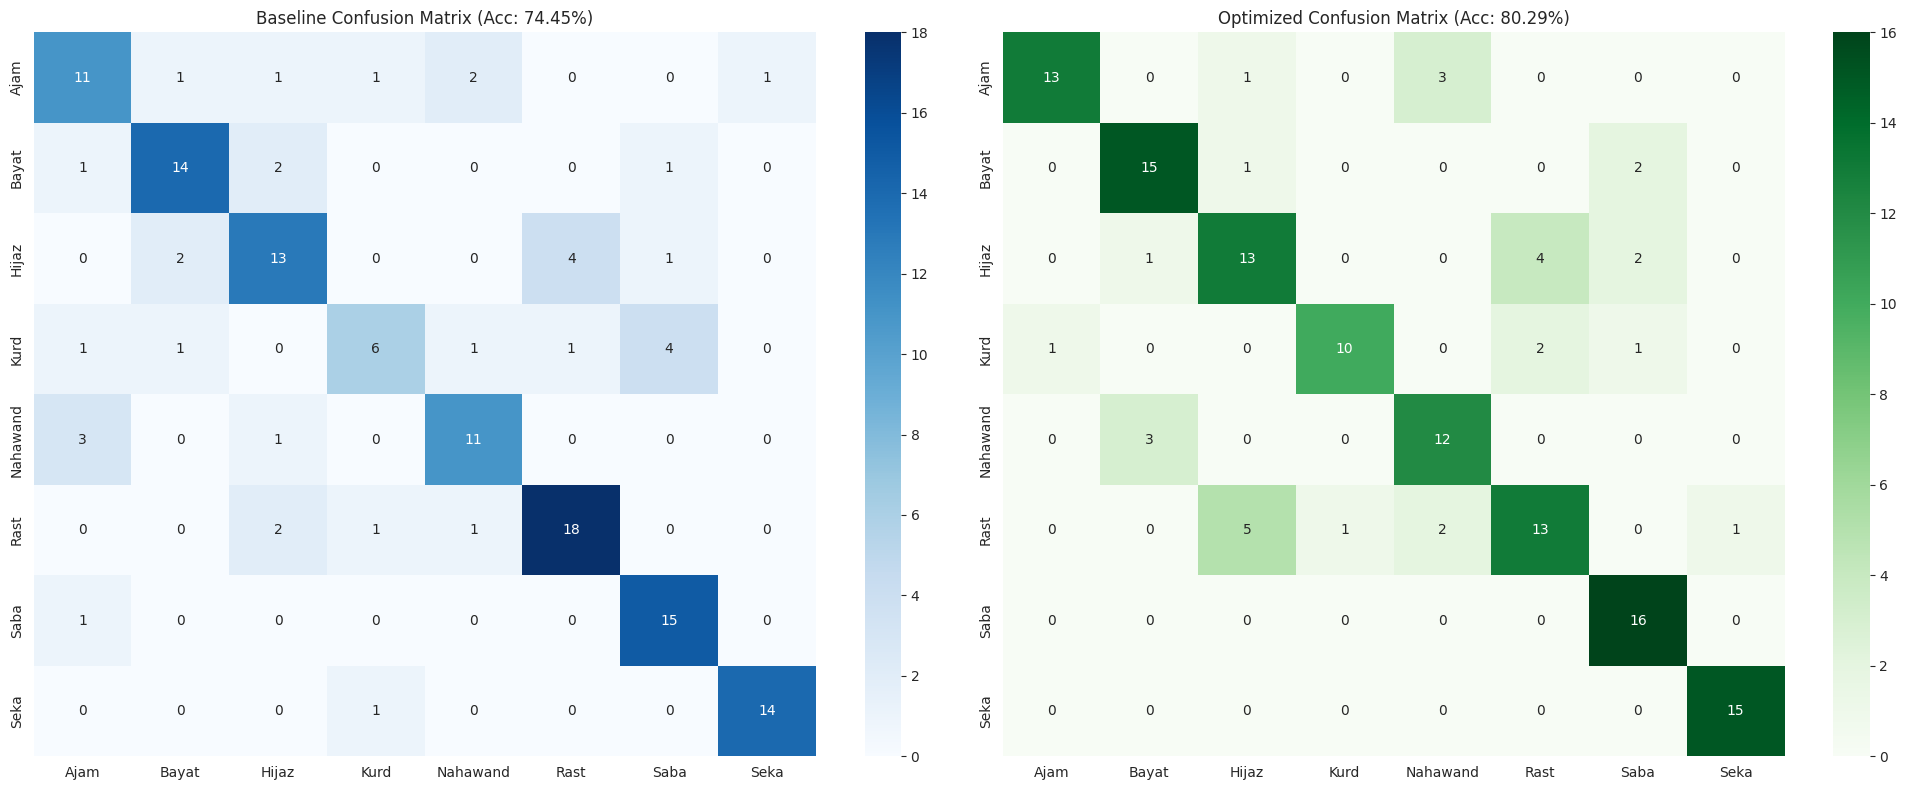

Optimized Classification Report:

              precision    recall  f1-score   support

        Ajam       0.93      0.76      0.84        17
       Bayat       0.79      0.83      0.81        18
       Hijaz       0.65      0.65      0.65        20
        Kurd       0.91      0.71      0.80        14
    Nahawand       0.71      0.80      0.75        15
        Rast       0.68      0.59      0.63        22
        Saba       0.76      1.00      0.86        16
        Seka       0.94      1.00      0.97        15

    accuracy                           0.78       137
   macro avg       0.80      0.79      0.79       137
weighted avg       0.79      0.78      0.78       137



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Instantiate model with Optuna's best parameters
best_params = study.best_trial.params
optimized_model = BiLSTM(
    input_size=input_dim,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    num_classes=classes_count,
    dropout_prob=best_params['dropout']
).to(device)

# 2. Retrain with optimized settings
optimizer = optim.Adam(optimized_model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

print("Retraining model with optimized hyperparameters...")
# Re-using the train_model function with the best patience
optimized_history = train_model(
    optimized_model, train_loader, test_loader, criterion, optimizer,
    num_epochs=50, device=device, patience=best_params['patience']
)

# 3. Load best state and evaluate
optimized_model.load_state_dict(torch.load('best_model.pth'))
optimized_model.eval()

opt_preds = []
opt_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = optimized_model(inputs)
        _, predicted = torch.max(outputs, 1)
        opt_preds.extend(predicted.cpu().numpy())
        opt_labels.extend(labels.numpy())

# 4. Visualization Comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Baseline (from previous 'cm' variable)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes)
axes[0].set_title(f'Baseline Confusion Matrix (Acc: 74.45%)')

# Optimized
cm_opt = confusion_matrix(opt_labels, opt_preds)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=classes, yticklabels=classes)
axes[1].set_title(f'Optimized Confusion Matrix (Acc: {study.best_trial.value:.2f}%)')

plt.tight_layout()
plt.show()

print("Optimized Classification Report:\n")
print(classification_report(opt_labels, opt_preds, target_names=classes))

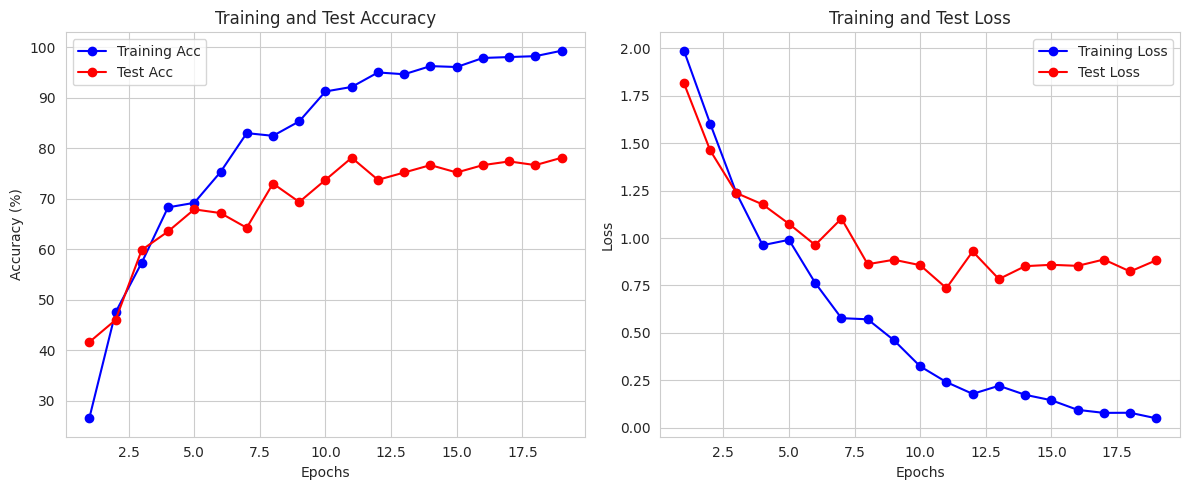

In [ ]:
# Reuse the plot_history function to visualize the optimized run
plot_history(optimized_history)

In [ ]:
import torch
from google.colab import files

# Save the optimized model weights
model_save_path = 'optimized_maqam_bilstm.pth'
torch.save(optimized_model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

# Optional: Trigger a browser download
# files.download(model_save_path)

Model weights saved to optimized_maqam_bilstm.pth
